# Electricity Demand Forecasting

Importing dependancies & dataset

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

Total Trading Days Recorded: 1623
Chronological Range: 2020-01-01 to 2026-03-27

First 5 Rows (Start of Data)
Price           Close
Date                 
2020-01-01  71.275803
2020-01-02  71.025002
2020-01-03  71.415001
2020-01-06  71.731003
2020-01-07  71.787003

 Last 5 Rows (Current 2026 Data)
Price           Close
Date                 
2026-03-23  93.895302
2026-03-24  93.243698
2026-03-25  94.299698
2026-03-26  94.693703
2026-03-27  94.309502


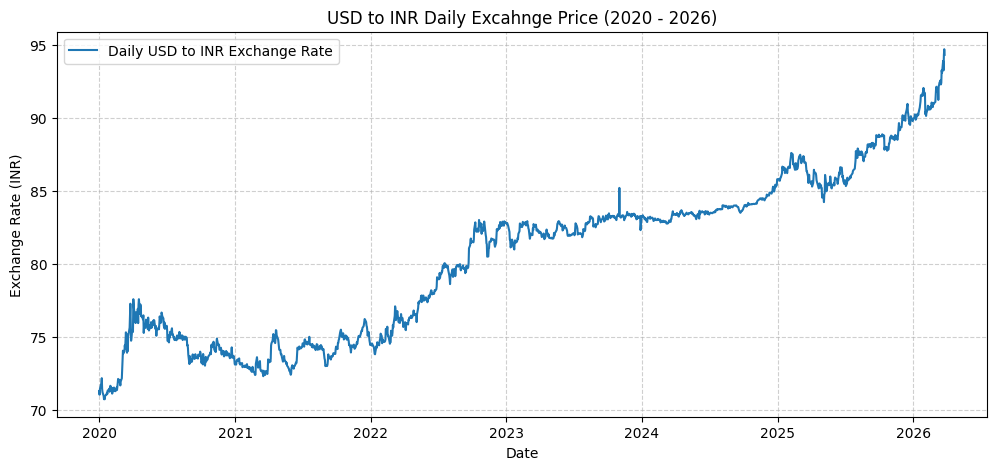

In [ ]:
#Downloading data from yfinance API
df = yf.download("INR=X", start="2020-01-01", progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Isolate the 'Close' price and drop any market holidays (NaN values)
df = df[['Close']].dropna()

print(f"Total Trading Days Recorded: {df.shape[0]}")
print(f"Chronological Range: {df.index.min().date()} to {df.index.max().date()}\n")
print("First 5 Rows (Start of Data)")
print(df.head())
print("\n Last 5 Rows (Current 2026 Data)")
print(df.tail())

# 3. Visualize Original Time Series Data
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], color='#1f77b4', linewidth=1.5, label='Daily USD to INR Exchange Rate')
plt.title('USD to INR Daily Excahnge Price (2020 - 2026)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Statistical Techniques and Data Preparations

Moving Average Analysis

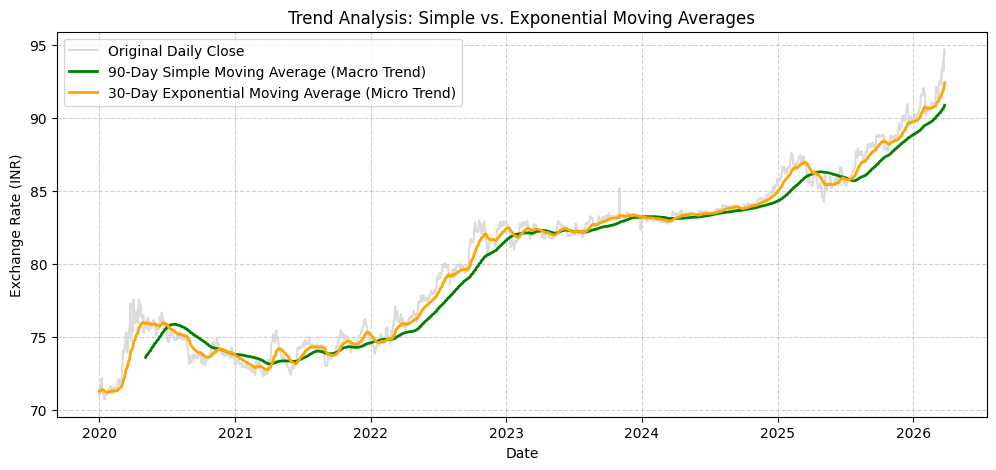

In [12]:
# Moving Average Analysis (SMA vs EMA)
df['SMA_90'] = df['Close'].rolling(window=90).mean()
df['EMA_30'] = df['Close'].ewm(span=30, adjust=False).mean()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], label='Original Daily Close', color='lightgray', alpha=0.8)
plt.plot(df.index, df['SMA_90'], label='90-Day Simple Moving Average (Macro Trend)', color='green', linewidth=2)
plt.plot(df.index, df['EMA_30'], label='30-Day Exponential Moving Average (Micro Trend)', color='orange', linewidth=2)

plt.title('Trend Analysis: Simple vs. Exponential Moving Averages')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

ADF Test

Augmented Dickey-Fuller Test (ADF)(Original Data)
ADF Statistic: 0.2325
p-value: 0.9740


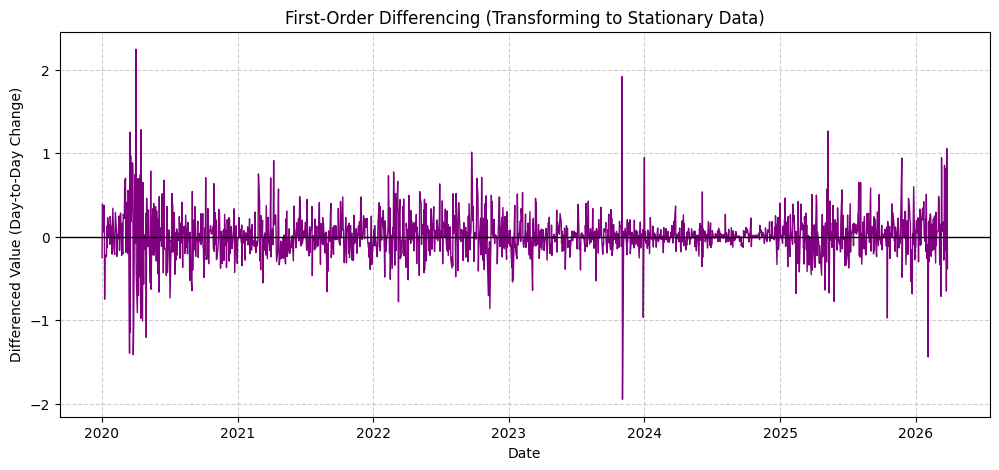


Augmented Dickey-Fuller Test (ADF)(Differenced Data)
ADF Statistic: -48.4628
p-value: 0.0000


In [14]:
# Stationarity Test
print("Augmented Dickey-Fuller Test (ADF)(Original Data)")
adf_result = adfuller(df['Close'])
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')

# Applying First-Order Differencing
df['Differenced'] = df['Close'].diff().dropna()

# Plotting the Differenced Data
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Differenced'], color='purple', linewidth=1)
plt.title('First-Order Differencing (Transforming to Stationary Data)')
plt.xlabel('Date')
plt.ylabel('Differenced Value (Day-to-Day Change)')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nAugmented Dickey-Fuller Test (ADF)(Differenced Data)")
adf_diff = adfuller(df['Differenced'].dropna())
print(f'ADF Statistic: {adf_diff[0]:.4f}')
print(f'p-value: {adf_diff[1]:.4f}')

#### ARIMA Forecasting

Training final model on complete dataset...


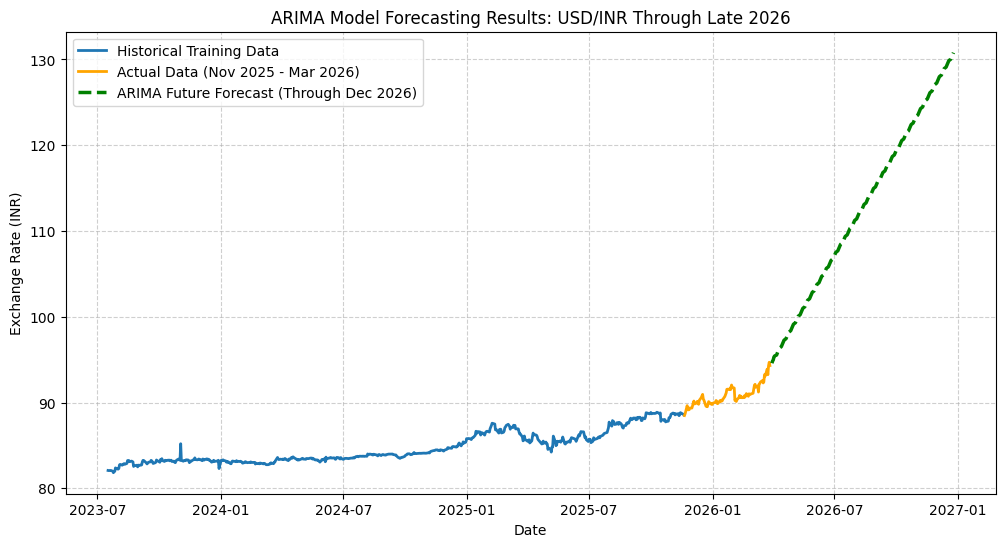

In [16]:
# 1. Train-Test Split (Last 90 days for testing)
train_data = df['Close'][:-90]
test_data = df['Close'][-90:]

# 2. Build Model for Testing
# We use ARIMA(5, 2, 0) exactly like the Gold Report to capture strong upward momentum
model_train = ARIMA(train_data, order=(5, 2, 0))
fitted_train = model_train.fit()

# Get predictions for the 90-day test period to evaluate accuracy later
test_predictions = fitted_train.forecast(steps=len(test_data))

# 3. Retrain on ALL Data for the True Future Forecast
# To predict the rest of 2026 accurately, the model must learn from the most recent 2026 data
print("Training final model on complete dataset...")
model_full = ARIMA(df['Close'], order=(5, 2, 0))
fitted_full = model_full.fit()

# Forecast out roughly 195 business days (Lands perfectly in late December 2026)
future_steps = 195
future_forecast = fitted_full.forecast(steps=future_steps)

# Create a clean date index for the future predictions starting tomorrow
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq='B')

# 4. Visualization of the Forecast
plt.figure(figsize=(12, 6))

# Plot Historical Data (Blue)
plt.plot(df.index[-700:-90], train_data[-610:], label='Historical Training Data', color='#1f77b4', linewidth=2)

# Plot Actual Test Data (Orange)
plt.plot(test_data.index, test_data, label='Actual Data (Nov 2025 - Mar 2026)', color='orange', linewidth=2)

# Plot the Future Forecast (Green Dashed)
plt.plot(future_dates, future_forecast, label='ARIMA Future Forecast (Through Dec 2026)', color='green', linestyle='dashed', linewidth=2.5)

plt.title('ARIMA Model Forecasting Results: USD/INR Through Late 2026')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Training final model on complete dataset...


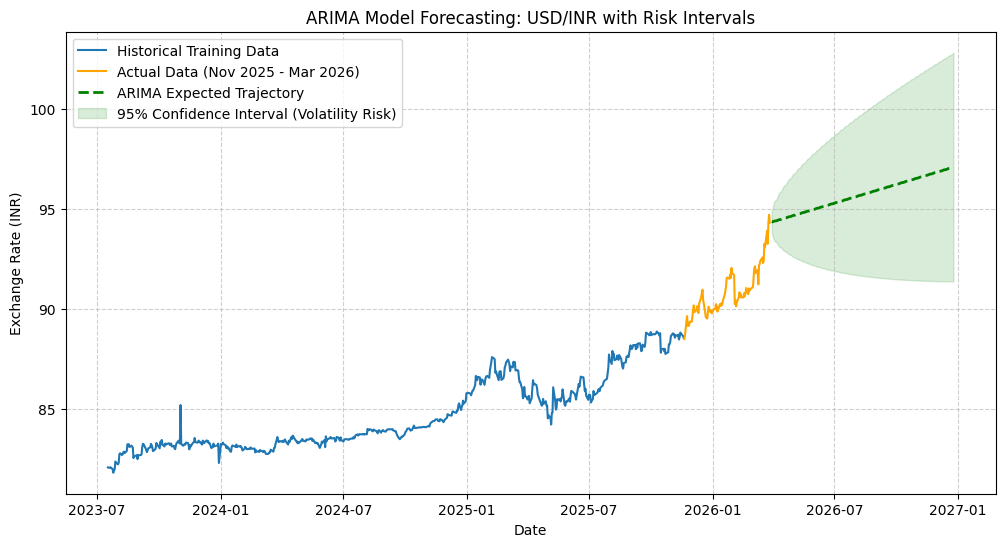

In [17]:
# 1. Train-Test Split (Last 90 days for testing)
train_data = df['Close'][:-90]
test_data = df['Close'][-90:]

# 2. Build Model for Testing
# Using (2, 1, 2) with a 't' (linear trend) to capture realistic steady growth, not hyperinflation
model_train = ARIMA(train_data, order=(2, 1, 2), trend='t')
fitted_train = model_train.fit()
test_predictions = fitted_train.forecast(steps=len(test_data))

# 3. Retrain on ALL Data for the True Future Forecast
print("Training final model on complete dataset...")
model_full = ARIMA(df['Close'], order=(2, 1, 2), trend='t')
fitted_full = model_full.fit()

# Get the forecast object which contains BOTH the mean line AND the confidence intervals
future_steps = 195
forecast_obj = fitted_full.get_forecast(steps=future_steps)
future_forecast = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05) # 95% Confidence Interval

# Create a clean date index for the future predictions
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq='B')

# 4. Visualization of the Proper Forecast
plt.figure(figsize=(12, 6))

# Plot Historical Data
plt.plot(df.index[-700:-90], train_data[-610:], label='Historical Training Data', color='#1f77b4', linewidth=1.5)

# Plot Actual Test Data
plt.plot(test_data.index, test_data, label='Actual Data (Nov 2025 - Mar 2026)', color='orange', linewidth=1.5)

# Plot the Future Forecast (The expected mean)
plt.plot(future_dates, future_forecast, label='ARIMA Expected Trajectory', color='green', linestyle='dashed', linewidth=2)

# Plot the Confidence Interval (The Volatility Cone)
plt.fill_between(future_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='green', alpha=0.15, label='95% Confidence Interval (Volatility Risk)')

plt.title('ARIMA Model Forecasting: USD/INR with Risk Intervals')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (INR)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()